In [1]:
import pandas as pd
import numpy as np

# ТЗ

Секция "Работа с данными"

Предположим в июле провели специальную акцию, направленную на улучшение ретеншена. Новым юзерам слали письмо с купоном. Сработала ли акция?

# Что такое Retention

Retention (удержание) — это одна из ключевых продуктовых метрик, которая показывает, возвращаются ли пользователи к вашему продукту или сервису с течением времени.

Проще говоря, это измерение лояльности и "липкости" вашего продукта.

Аналогия из жизни:
Представьте, что вы открыли спортзал. В первый день пришло 100 новых посетителей по акции.

- На следующий день вернулись 30 человек. Retention Day 1 = 30%.

- Через неделю продолжают ходить 15 человек. Retention Day 7 = 15%.

- Через месяц остались 5 преданных клиентов. Retention Day 30 = 5%.

Анализ retention помогает понять:

- Насколько продукт нужен людям. Высокий retention = люди находят ценность.

- Где "сыпятся" пользователи. Если на 2-й день уходит 70%, проблема в самом первом опыте (Onboarding).

- Эффективность новых функций. Выпустили обновление — retention вырос или упал?

- Прогнозировать долгосрочный рост. Удержать текущего пользователя почти всегда дешевле, чем найти нового.

# Загрузка данных

In [7]:
# https://drive.google.com/file/d/18CZKLXpbZfR44SunmzSuFvc0kI9U8n_K/view
file_url_1 = 'https://drive.google.com/uc?export=download&id=18CZKLXpbZfR44SunmzSuFvc0kI9U8n_K'
df = pd.read_csv(file_url_1)

In [8]:
df.head()

,user_id,order_id,reg_date,transaction_date,revenue
0,57562,94545.0,2013-12-22,2015-07-16,1088
1,40047,81824.0,2013-11-24,2015-01-19,1027
2,48153,144851.0,2015-07-03,2015-10-29,601
3,54591,116111.0,2013-07-12,2015-04-30,881
4,39789,134943.0,2013-05-25,2015-07-21,984


# EDA

In [10]:
df.columns

Index(['user_id', 'order_id', 'reg_date', 'transaction_date', 'revenue'], dtype='object')

In [11]:
df.index

RangeIndex(start=0, stop=76857, step=1)

In [380]:
df['user_id'].nunique()

48214

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76857 entries, 0 to 76856
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           76857 non-null  int64  
 1   order_id          76857 non-null  float64
 2   reg_date          76857 non-null  object 
 3   transaction_date  76857 non-null  object 
 4   revenue           76857 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 2.9+ MB


## Приведение форматов данных

In [14]:
df['reg_date'] = pd.to_datetime(df['reg_date'], format='%Y-%m-%d')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%Y-%m-%d')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76857 entries, 0 to 76856
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           76857 non-null  int64         
 1   order_id          76857 non-null  float64       
 2   reg_date          76857 non-null  datetime64[ns]
 3   transaction_date  76857 non-null  datetime64[ns]
 4   revenue           76857 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2)
memory usage: 2.9 MB


In [16]:
# Метод astype() в библиотеке Pandas (Python) — это инструмент для преобразования типов данных.
df['order_id'] = df['order_id'].astype('int64')

In [17]:
len(df)

76857

In [18]:
df['reg_date'].agg(['min','max'])

min   1900-01-01
max   2015-11-20
Name: reg_date, dtype: datetime64[ns]

## Выделение месяца из даты

In [20]:
#первый день месяца даты регистрации
df['reg_month'] = df['reg_date'].to_numpy().astype('datetime64[M]')

In [21]:
df

,user_id,order_id,reg_date,transaction_date,revenue,reg_month
0,57562,94545,2013-12-22,2015-07-16,1088,2013-12-01
1,40047,81824,2013-11-24,2015-01-19,1027,2013-11-01
2,48153,144851,2015-07-03,2015-10-29,601,2015-07-01
3,54591,116111,2013-07-12,2015-04-30,881,2013-07-01
4,39789,134943,2013-05-25,2015-07-21,984,2013-05-01
...,...,...,...,...,...,...
76852,36921,163682,2015-01-15,2015-03-28,1095,2015-01-01
76853,31360,145146,2015-01-04,2015-08-09,547,2015-01-01
76854,56195,8929,2012-09-18,2015-11-12,850,2012-09-01
76855,46362,78673,2015-02-20,2015-07-21,356,2015-02-01


In [22]:
df.groupby('reg_month')['user_id'].agg(['count','nunique'])

,count,nunique
reg_month,,
1900-01-01,53,53
2012-02-01,9,9
2012-03-01,362,361
2012-04-01,370,370
2012-05-01,301,301
2012-06-01,445,443
2012-07-01,370,369
2012-08-01,271,269
2012-09-01,356,355


In [23]:
#первый день месяца даты транзакции
df['transaction_month'] = df['transaction_date'].to_numpy().astype('datetime64[M]')

In [24]:
df.groupby('transaction_month')['user_id'].agg(['count','nunique'])

,count,nunique
transaction_month,,
2015-01-01,4058,3951
2015-02-01,4932,4777
2015-03-01,5824,5599
2015-04-01,6102,5862
2015-05-01,6339,6063
2015-06-01,6829,6480
2015-07-01,7520,7166
2015-08-01,8598,8110
2015-09-01,8468,7964


# Создаем таблицу Пользователь/Месяц регистрации

In [26]:
# в каком месяце зарегистрировался каждый пользователь
user = df.groupby('user_id')['reg_month'].min().reset_index()

In [27]:
user

,user_id,reg_month
0,-37599,2015-01-01
1,-32239,2015-11-01
2,-29822,2015-07-01
3,-29531,2014-09-01
4,-25337,2015-04-01
...,...,...
48209,128964,2015-10-01
48210,130617,2015-02-01
48211,131071,2012-04-01
48212,132484,2015-06-01


In [28]:
df['user_id'].nunique()

48214

# Создаем таблицу "Месяц транзакции"

## Число месяцев транзакций

In [31]:
len(df.groupby('transaction_month')['user_id'].agg(['count','nunique']))

11

## Создаем диапазоны дат (календарь)

In [33]:
min = df['transaction_date'].min()
max = df['transaction_date'].max()

In [34]:
month = pd.DataFrame(pd.date_range(min, max, freq='MS'))
month.columns = ['month']
month

,month
0,2015-01-01
1,2015-02-01
2,2015-03-01
3,2015-04-01
4,2015-05-01
5,2015-06-01
6,2015-07-01
7,2015-08-01
8,2015-09-01
9,2015-10-01


In [35]:
user['key'] = 1
month['key'] = 1

In [36]:
user.head()

,user_id,reg_month,key
0,-37599,2015-01-01,1
1,-32239,2015-11-01,1
2,-29822,2015-07-01,1
3,-29531,2014-09-01,1
4,-25337,2015-04-01,1


In [37]:
month.head()

,month,key
0,2015-01-01,1
1,2015-02-01,1
2,2015-03-01,1
3,2015-04-01,1
4,2015-05-01,1


# Merge таблиц (Cross Join)

Идея в том, чтобы получить пользователя, его месяц регистрации (таблица user) и его месяц активности/транзакций (month). Для этого используется cross join, т.е. каждая строка таблицы user соединяется с каждой строкой таблицы month.

In [40]:
template = user.merge(month, on='key')[['user_id', 'reg_month', 'month']]

Есть такие месяца, где пользователь еще не зарегистрировался

In [42]:
template.head()

,user_id,reg_month,month
0,-37599,2015-01-01,2015-01-01
1,-37599,2015-01-01,2015-02-01
2,-37599,2015-01-01,2015-03-01
3,-37599,2015-01-01,2015-04-01
4,-37599,2015-01-01,2015-05-01


In [43]:
len(template)

530354

In [44]:
# фильтруем
# Например, для пользователя который зарегался в ноябре, не нужны даты транзакций до ноября.
template = template[template['month']>=template['reg_month']]

In [45]:
template.head(12)

,user_id,reg_month,month
0,-37599,2015-01-01,2015-01-01
1,-37599,2015-01-01,2015-02-01
2,-37599,2015-01-01,2015-03-01
3,-37599,2015-01-01,2015-04-01
4,-37599,2015-01-01,2015-05-01
5,-37599,2015-01-01,2015-06-01
6,-37599,2015-01-01,2015-07-01
7,-37599,2015-01-01,2015-08-01
8,-37599,2015-01-01,2015-09-01
9,-37599,2015-01-01,2015-10-01


# Создаем таблицу Транзакции

In [47]:
df.head()

,user_id,order_id,reg_date,transaction_date,revenue,reg_month,transaction_month
0,57562,94545,2013-12-22,2015-07-16,1088,2013-12-01,2015-07-01
1,40047,81824,2013-11-24,2015-01-19,1027,2013-11-01,2015-01-01
2,48153,144851,2015-07-03,2015-10-29,601,2015-07-01,2015-10-01
3,54591,116111,2013-07-12,2015-04-30,881,2013-07-01,2015-04-01
4,39789,134943,2013-05-25,2015-07-21,984,2013-05-01,2015-07-01


In [48]:
# Может быть несколько транзакицй на одну дату
df.groupby(['user_id','transaction_date'])['revenue'].count().sort_values(ascending=False)

user_id  transaction_date
25374    2015-09-02          2
45159    2015-04-30          2
40999    2015-04-08          2
50299    2015-09-15          2
18648    2015-08-20          2
                            ..
41455    2015-08-17          1
41454    2015-07-11          1
41452    2015-03-01          1
41450    2015-06-07          1
138987   2015-06-03          1
Name: revenue, Length: 76745, dtype: int64

In [49]:
# сумма транзакции пользователя на конкретную дату
trans_month = df.groupby(['user_id','transaction_month'])['revenue'].sum().reset_index()

In [50]:
trans_month.head()

,user_id,transaction_month,revenue
0,-37599,2015-03-01,1182
1,-32239,2015-11-01,727
2,-29822,2015-09-01,908
3,-29531,2015-06-01,1462
4,-25337,2015-07-01,899


In [51]:
trans_month.columns = ['user_id', 'month', 'revenue']

In [52]:
trans_month.head()

,user_id,month,revenue
0,-37599,2015-03-01,1182
1,-32239,2015-11-01,727
2,-29822,2015-09-01,908
3,-29531,2015-06-01,1462
4,-25337,2015-07-01,899


# Merge таблиц

In [54]:
# соединяем по пользователю и месяцу транзакции через left join, т.к. есть месяца без транзакций
report = template.merge(trans_month, how='left', on=['user_id', 'month'])

In [55]:
report['active'] = (report['revenue'] > 0)*1

In [56]:
report

,user_id,reg_month,month,revenue,active
0,-37599,2015-01-01,2015-01-01,NaN,0
1,-37599,2015-01-01,2015-02-01,NaN,0
2,-37599,2015-01-01,2015-03-01,1182.0,1
3,-37599,2015-01-01,2015-04-01,NaN,0
4,-37599,2015-01-01,2015-05-01,NaN,0
...,...,...,...,...,...
467620,138987,2014-10-01,2015-07-01,NaN,0
467621,138987,2014-10-01,2015-08-01,NaN,0
467622,138987,2014-10-01,2015-09-01,NaN,0
467623,138987,2014-10-01,2015-10-01,NaN,0


# Считаем Retention

In [58]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


Таблица показывает активность пользователей за 2015 год, которые зарегистрировались в определенный период времени

In [60]:
retention = report.pivot_table(index='reg_month', columns='month', values='active', aggfunc='mean')

In [61]:
retention

month,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01
reg_month,,,,,,,,,,,
1900-01-01,0.150943,0.169811,0.339623,0.150943,0.169811,0.245283,0.113208,0.094340,0.094340,0.169811,0.094340
2012-02-01,0.111111,0.222222,0.111111,0.000000,0.444444,0.222222,0.222222,0.222222,0.222222,0.000000,0.222222
2012-03-01,0.146814,0.157895,0.124654,0.152355,0.146814,0.182825,0.168975,0.193906,0.177285,0.293629,0.160665
2012-04-01,0.146341,0.138211,0.230352,0.168022,0.168022,0.170732,0.170732,0.165312,0.176152,0.241192,0.178862
2012-05-01,0.097315,0.157718,0.167785,0.187919,0.187919,0.181208,0.177852,0.248322,0.174497,0.211409,0.181208
2012-06-01,0.116972,0.142202,0.146789,0.206422,0.172018,0.160550,0.162844,0.158257,0.197248,0.243119,0.176606
2012-07-01,0.136490,0.142061,0.153203,0.175487,0.167131,0.153203,0.181058,0.192201,0.147632,0.261838,0.186630
2012-08-01,0.079545,0.151515,0.185606,0.200758,0.151515,0.151515,0.193182,0.215909,0.204545,0.250000,0.189394
2012-09-01,0.156522,0.130435,0.153623,0.191304,0.165217,0.171014,0.144928,0.173913,0.165217,0.194203,0.144928


In [62]:
retention = report[report['reg_month'] >= '2015-01-01'].pivot_table(index='reg_month', columns='month', values='active', aggfunc='mean')

In [63]:
retention

month,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01
reg_month,,,,,,,,,,,
2015-01-01,0.116928,0.116056,0.129581,0.116492,0.115183,0.124782,0.118237,0.131326,0.126091,0.148778,0.114311
2015-02-01,NaN,0.132856,0.141543,0.135922,0.121615,0.122126,0.119571,0.123659,0.149208,0.163005,0.105263
2015-03-01,NaN,NaN,0.164114,0.138403,0.129650,0.127462,0.138403,0.145514,0.138950,0.170678,0.117068
2015-04-01,NaN,NaN,NaN,0.193627,0.158088,0.144608,0.136029,0.161152,0.137255,0.167892,0.127451
2015-05-01,NaN,NaN,NaN,NaN,0.246457,0.184252,0.154331,0.136220,0.152756,0.159055,0.132283
2015-06-01,NaN,NaN,NaN,NaN,NaN,0.257924,0.216283,0.180236,0.168428,0.189559,0.141703
2015-07-01,NaN,NaN,NaN,NaN,NaN,NaN,0.283110,0.331367,0.179088,0.181769,0.124397
2015-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.423358,0.268613,0.222628,0.157664
2015-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.429314,0.381497,0.221414


In [64]:
report.pivot_table(index='reg_month', columns='month', values='active', aggfunc='sum')

month,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01
reg_month,,,,,,,,,,,
1900-01-01,8.0,9.0,18.0,8.0,9.0,13.0,6.0,5.0,5.0,9.0,5.0
2012-02-01,1.0,2.0,1.0,0.0,4.0,2.0,2.0,2.0,2.0,0.0,2.0
2012-03-01,53.0,57.0,45.0,55.0,53.0,66.0,61.0,70.0,64.0,106.0,58.0
2012-04-01,54.0,51.0,85.0,62.0,62.0,63.0,63.0,61.0,65.0,89.0,66.0
2012-05-01,29.0,47.0,50.0,56.0,56.0,54.0,53.0,74.0,52.0,63.0,54.0
2012-06-01,51.0,62.0,64.0,90.0,75.0,70.0,71.0,69.0,86.0,106.0,77.0
2012-07-01,49.0,51.0,55.0,63.0,60.0,55.0,65.0,69.0,53.0,94.0,67.0
2012-08-01,21.0,40.0,49.0,53.0,40.0,40.0,51.0,57.0,54.0,66.0,50.0
2012-09-01,54.0,45.0,53.0,66.0,57.0,59.0,50.0,60.0,57.0,67.0,50.0


## Делаем heatmap

In [66]:
import seaborn as sns

<Axes: xlabel='month', ylabel='reg_month'>

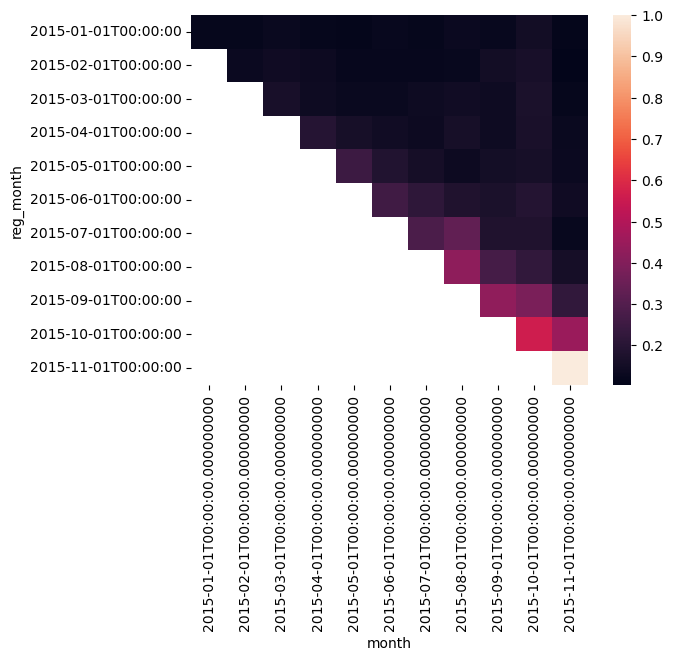

In [67]:
sns.heatmap(retention)

In [68]:
retention

month,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01
reg_month,,,,,,,,,,,
2015-01-01,0.116928,0.116056,0.129581,0.116492,0.115183,0.124782,0.118237,0.131326,0.126091,0.148778,0.114311
2015-02-01,NaN,0.132856,0.141543,0.135922,0.121615,0.122126,0.119571,0.123659,0.149208,0.163005,0.105263
2015-03-01,NaN,NaN,0.164114,0.138403,0.129650,0.127462,0.138403,0.145514,0.138950,0.170678,0.117068
2015-04-01,NaN,NaN,NaN,0.193627,0.158088,0.144608,0.136029,0.161152,0.137255,0.167892,0.127451
2015-05-01,NaN,NaN,NaN,NaN,0.246457,0.184252,0.154331,0.136220,0.152756,0.159055,0.132283
2015-06-01,NaN,NaN,NaN,NaN,NaN,0.257924,0.216283,0.180236,0.168428,0.189559,0.141703
2015-07-01,NaN,NaN,NaN,NaN,NaN,NaN,0.283110,0.331367,0.179088,0.181769,0.124397
2015-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.423358,0.268613,0.222628,0.157664
2015-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.429314,0.381497,0.221414


# Retention по Lifetime

Здесь LifeTime - это сколько месяцев прошло с момента регистрации пользователя до момента совершения им транзакции

In [71]:
report['month'].dt.to_period('M').astype('int64')

0         540
1         541
2         542
3         543
4         544
         ... 
467620    546
467621    547
467622    548
467623    549
467624    550
Name: month, Length: 467625, dtype: int64

In [72]:
report['lifetime'] = report['month'].dt.to_period('M').astype('int64') - report['reg_month'].dt.to_period('M').astype('int64')

In [73]:
# не робит
#report['lifetime'] = (report['month'] - report['reg_month'])/np.timedelta64(1, 'M')

In [74]:
report[report['reg_month'] =='2012-10-01'].head()

,user_id,reg_month,month,revenue,active,lifetime
2591,-3478,2012-10-01,2015-01-01,NaN,0,27
2592,-3478,2012-10-01,2015-02-01,NaN,0,28
2593,-3478,2012-10-01,2015-03-01,NaN,0,29
2594,-3478,2012-10-01,2015-04-01,1250.0,1,30
2595,-3478,2012-10-01,2015-05-01,NaN,0,31


In [75]:
retention = report[report['reg_month'] >= '2015-01-01'].pivot_table(index='reg_month', columns='lifetime', values='active', aggfunc='mean')

In [76]:
retention

lifetime,0,1,2,3,4,5,6,7,8,9,10
reg_month,,,,,,,,,,,
2015-01-01,0.116928,0.116056,0.129581,0.116492,0.115183,0.124782,0.118237,0.131326,0.126091,0.148778,0.114311
2015-02-01,0.132856,0.141543,0.135922,0.121615,0.122126,0.119571,0.123659,0.149208,0.163005,0.105263,NaN
2015-03-01,0.164114,0.138403,0.129650,0.127462,0.138403,0.145514,0.138950,0.170678,0.117068,NaN,NaN
2015-04-01,0.193627,0.158088,0.144608,0.136029,0.161152,0.137255,0.167892,0.127451,NaN,NaN,NaN
2015-05-01,0.246457,0.184252,0.154331,0.136220,0.152756,0.159055,0.132283,NaN,NaN,NaN,NaN
2015-06-01,0.257924,0.216283,0.180236,0.168428,0.189559,0.141703,NaN,NaN,NaN,NaN,NaN
2015-07-01,0.283110,0.331367,0.179088,0.181769,0.124397,NaN,NaN,NaN,NaN,NaN,NaN
2015-08-01,0.423358,0.268613,0.222628,0.157664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-09-01,0.429314,0.381497,0.221414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='lifetime', ylabel='reg_month'>

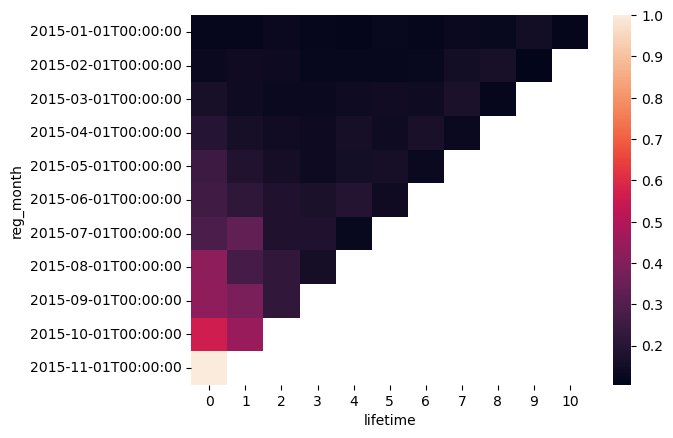

In [77]:
sns.heatmap(retention)

Видим, что retention сильно вырос для пользователей, в 8 месяце (августе)

# Retention в SQL

## Подготовка

In [81]:
# Импортировать модуль
import sqlite3

In [82]:
# Установить соединение с файлом БД
conn = sqlite3.connect('db')

In [83]:
#Создать курсор
cur = conn.cursor()

In [84]:
# функция для вызова sql запроса
def select(sql):
  return pd.read_sql(sql,conn)

In [85]:
# или вот так
sql = pd.read_sql_query("SELECT * FROM trans", conn)

## Загрузка данных

In [87]:
df = pd.read_csv(file_url_1)

In [88]:
df['reg_date'] = pd.to_datetime(df['reg_date'], format='%Y-%m-%d')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%Y-%m-%d')

In [89]:
df.to_sql('trans', conn, index=False, if_exists='replace')

76857

In [90]:
sql = ''' SELECT * FROM trans t '''

In [91]:
select(sql)

,user_id,order_id,reg_date,transaction_date,revenue
0,57562,94545.0,2013-12-22 00:00:00,2015-07-16 00:00:00,1088
1,40047,81824.0,2013-11-24 00:00:00,2015-01-19 00:00:00,1027
2,48153,144851.0,2015-07-03 00:00:00,2015-10-29 00:00:00,601
3,54591,116111.0,2013-07-12 00:00:00,2015-04-30 00:00:00,881
4,39789,134943.0,2013-05-25 00:00:00,2015-07-21 00:00:00,984
...,...,...,...,...,...
76852,36921,163682.0,2015-01-15 00:00:00,2015-03-28 00:00:00,1095
76853,31360,145146.0,2015-01-04 00:00:00,2015-08-09 00:00:00,547
76854,56195,8929.0,2012-09-18 00:00:00,2015-11-12 00:00:00,850
76855,46362,78673.0,2015-02-20 00:00:00,2015-07-21 00:00:00,356


## Пользователь и его дата регистрации

In [233]:
sql = ''' SELECT user_id, DATE(MIN(reg_date), 'start of month') AS reg_month
          FROM trans t
          GROUP BY user_id
          '''

In [235]:
select(sql)

,user_id,reg_month
0,-37599,2015-01-01
1,-32239,2015-11-01
2,-29822,2015-07-01
3,-29531,2014-09-01
4,-25337,2015-04-01
...,...,...
48209,128964,2015-10-01
48210,130617,2015-02-01
48211,131071,2012-04-01
48212,132484,2015-06-01


## Генерируем диапазон дат транзакций

In [199]:
min = '''SELECT DATE(MIN(transaction_date), 'start of month')
        FROM trans t'''

In [201]:
max = '''SELECT DATE(MAX(transaction_date), 'start of month')
        FROM trans t'''

In [203]:
select(min)

,"DATE(MIN(transaction_date), 'start of month')"
0,2015-01-01


In [205]:
select(max)

,"DATE(MAX(transaction_date), 'start of month')"
0,2015-11-01


In [207]:
sql = f'''WITH RECURSIVE dates(date) AS (
         VALUES(({min}))
         UNION ALL
         SELECT date(date, '+1 month')
         FROM dates
         WHERE date < ({max})
)
SELECT date FROM dates;'''

In [209]:
select(sql)

,date
0,2015-01-01
1,2015-02-01
2,2015-03-01
3,2015-04-01
4,2015-05-01
5,2015-06-01
6,2015-07-01
7,2015-08-01
8,2015-09-01
9,2015-10-01


## Cross Join

In [245]:
# Первая и вторая таблица помещаются в CTE, затем джоинятся

In [343]:
sql = f'''WITH
users AS
    (SELECT user_id, DATE(MIN(reg_date), 'start of month') AS reg_month
    FROM trans t
    GROUP BY user_id),

dates AS (WITH RECURSIVE dates(date) AS (
    VALUES(({min}))
    UNION ALL
    SELECT date(date, '+1 month')
    FROM dates
    WHERE date < ({max})
)
SELECT date FROM dates)

--таблица template
    SELECT t.user_id, t.reg_month, d.date AS month
    FROM users t
    JOIN dates d on 1=1
    WHERE d.date >= t.reg_month

          '''

In [345]:
select(sql)

,user_id,reg_month,month
0,-37599,2015-01-01,2015-01-01
1,-37599,2015-01-01,2015-02-01
2,-37599,2015-01-01,2015-03-01
3,-37599,2015-01-01,2015-04-01
4,-37599,2015-01-01,2015-05-01
...,...,...,...
467620,138987,2014-10-01,2015-07-01
467621,138987,2014-10-01,2015-08-01
467622,138987,2014-10-01,2015-09-01
467623,138987,2014-10-01,2015-10-01


## Помесячно группируем все транзакции, делаем left join к таблице template

`Важный принцип CTE состоит в том, что к результату CTE можно обратиться только один раз`

In [363]:
sql = f'''WITH
users AS
    (SELECT user_id, DATE(MIN(reg_date), 'start of month') AS reg_month
    FROM trans t
    GROUP BY user_id),

dates AS (WITH RECURSIVE dates(date) AS (
    VALUES(({min}))
    UNION ALL
    SELECT date(date, '+1 month')
    FROM dates
    WHERE date < ({max})
)
SELECT date FROM dates),

template AS(
    SELECT t.user_id, t.reg_month, d.date AS month
    FROM users t
    JOIN dates d on 1=1
    WHERE d.date >= t.reg_month),
    
--помесячно группируем все транзакции
trans_month AS (
    SELECT t.user_id, date(t.transaction_date, 'start of month') AS month,
    SUM(t.revenue) AS revenue_sum,
    COUNT(*) AS transaction_cnt
    FROM trans t
    GROUP BY t.user_id, date(t.transaction_date, 'start of month')
),

--делаем left join к таблице template
report AS (
    SELECT t.*, tm.revenue_sum, tm.transaction_cnt,
    CASE WHEN tm.revenue_sum > 0 THEN 1 ELSE 0 END AS active,
    ROUND((julianday(t.month) - julianday(t.reg_month))/30) AS lifetime
    FROM template t
    LEFT JOIN trans_month tm ON t.user_id = tm.user_id AND t.month = tm.month)

--считаем retention, отбираем нужные записи
SELECT t.reg_month, t.lifetime, AVG(t.active) AS retention
FROM report t
WHERE t.reg_month >= '2015-01-01'
GROUP BY t.reg_month, t.lifetime
          '''

In [365]:
t = select(sql)

In [367]:
t

,reg_month,lifetime,retention
0,2015-01-01,0.0,0.116928
1,2015-01-01,1.0,0.116056
2,2015-01-01,2.0,0.129581
3,2015-01-01,3.0,0.116492
4,2015-01-01,4.0,0.115183
...,...,...,...
61,2015-09-01,1.0,0.381497
62,2015-09-01,2.0,0.221414
63,2015-10-01,0.0,0.561974
64,2015-10-01,1.0,0.448857


## Делаем сводную таблицу

In [369]:
t.pivot_table(index='reg_month', columns='lifetime', values='retention', aggfunc='max')

lifetime,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
reg_month,,,,,,,,,,,
2015-01-01,0.116928,0.116056,0.129581,0.116492,0.115183,0.124782,0.118237,0.131326,0.126091,0.148778,0.114311
2015-02-01,0.132856,0.141543,0.135922,0.121615,0.122126,0.119571,0.123659,0.149208,0.163005,0.105263,NaN
2015-03-01,0.164114,0.138403,0.129650,0.127462,0.138403,0.145514,0.138950,0.170678,0.117068,NaN,NaN
2015-04-01,0.193627,0.158088,0.144608,0.136029,0.161152,0.137255,0.167892,0.127451,NaN,NaN,NaN
2015-05-01,0.246457,0.184252,0.154331,0.136220,0.152756,0.159055,0.132283,NaN,NaN,NaN,NaN
2015-06-01,0.257924,0.216283,0.180236,0.168428,0.189559,0.141703,NaN,NaN,NaN,NaN,NaN
2015-07-01,0.283110,0.331367,0.179088,0.181769,0.124397,NaN,NaN,NaN,NaN,NaN,NaN
2015-08-01,0.423358,0.268613,0.222628,0.157664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-09-01,0.429314,0.381497,0.221414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Сравниваем с результатом в pandas

In [371]:
retention

lifetime,0,1,2,3,4,5,6,7,8,9,10
reg_month,,,,,,,,,,,
2015-01-01,0.116928,0.116056,0.129581,0.116492,0.115183,0.124782,0.118237,0.131326,0.126091,0.148778,0.114311
2015-02-01,0.132856,0.141543,0.135922,0.121615,0.122126,0.119571,0.123659,0.149208,0.163005,0.105263,NaN
2015-03-01,0.164114,0.138403,0.129650,0.127462,0.138403,0.145514,0.138950,0.170678,0.117068,NaN,NaN
2015-04-01,0.193627,0.158088,0.144608,0.136029,0.161152,0.137255,0.167892,0.127451,NaN,NaN,NaN
2015-05-01,0.246457,0.184252,0.154331,0.136220,0.152756,0.159055,0.132283,NaN,NaN,NaN,NaN
2015-06-01,0.257924,0.216283,0.180236,0.168428,0.189559,0.141703,NaN,NaN,NaN,NaN,NaN
2015-07-01,0.283110,0.331367,0.179088,0.181769,0.124397,NaN,NaN,NaN,NaN,NaN,NaN
2015-08-01,0.423358,0.268613,0.222628,0.157664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-09-01,0.429314,0.381497,0.221414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
